# **Analyse de l’attrition de la clientèle d’un operateur téléphonique**

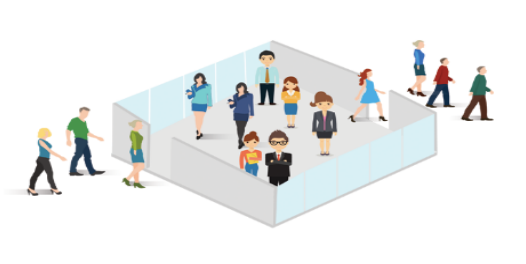

> **📌 Corrections apportées à la section Modélisation (4.2)**
>
> - Le split train/test est désormais **stratifié** et **reproductible** (`stratify=y`, `random_state=42`) — l'original ne l'était pas.
> - **Comparaison de 3 modèles** (régression logistique, arbre de décision, Random Forest) par **validation croisée**, là où l'original entraînait un seul arbre sans jamais le valider ni le comparer à d'autres approches.
> - **Métriques adaptées au déséquilibre des classes** (ROC-AUC, Average Precision / PR-AUC, F1-macro) en complément de l'accuracy — l'original ne reportait que le F1/precision en moyenne `micro`, mathématiquement égal à l'accuracy et donc trompeur sur un jeu de données à 81%/19%.
> - **Optimisation d'hyperparamètres** (`RandomizedSearchCV`) — les imports `GridSearchCV`/`RandomizedSearchCV` étaient présents dans l'original mais jamais utilisés.
> - **Courbes ROC et Précision-Rappel**, matrice de confusion, importance des variables.
> - **Ajustement du seuil de décision** : le modèle original, évalué au seuil par défaut de 0.5, ne détectait que **8% des clients qui se désabonnent réellement** (rappel = 0.08) malgré un F1-score/accuracy affiché de 96% — un résultat trompeur, quasiment inutile pour l'objectif métier. La nouvelle section 4.2.4 corrige ce point et donne un vrai levier de décision.
> - Nettoyage des imports morts/sans rapport (jeux de données `iris`/`breast_cancer`, `pyparsing`) et correction de l'arbre d'illustration qui utilisait des noms de colonnes écrits en dur, dans un ordre non garanti.
>
> *(Le reste du notebook — analyse exploratoire, tests statistiques, recommandations — est inchangé.)*

---


# **Résumé**
 Le churn qui désigne la perte de clients ou d’abonnés constitue une vraie problématique pour les organisations dans différents secteurs d’activité y compris le secteur de la téléphonie. En sachant qu’il existe une érosion naturelle des clients dans ce secteur,l’étude sur le churn a récemment suscité un intérêt considérable pour les parties prenantes en raison des pertes de revenus associées


Le but de cette étude est de faire une analyse de l’attrition des clients (churn) afin de mieux comprendre les causes (les facteurs les plus pertinents) de ce phénomène, et ainsi réduire son impact au sein d’une société de télécommunication avec une stratégie adaptée.


Dans ce projet, nous partirons sur une base de données clients que nous exploiterons afin d’analyser les différents facteurs de l’attrition des clients et de déterminer le modèle le plus adapté afin de prédire cette attrition avant de proposer une stratégie de fidélisation de la clientèle.








# **1  Spécification détaillée des besoins**

Les entreprises de téléphonie génèrent une énorme quantité de données. Ces données incluent des données détaillées d'appel, qui décrivent les appels qui traversent les réseaux de télécommunication, les données réseau et de géolocalisation, qui fournissent des informations sur les clients. L’analyse de celles-ci pourrait permettre la prédiction de comportements atypiques et la détection de fraude téléphonique, la possibilité qu’un client abandonne les services de l’opérateur, etc. Dans le cadre de ce mémoire, nous étudions le phénomène de désabonnement des clients communément appelé “analyse de l’attrition de la clientèle". En d’autres termes, nous nous intéressons aux facteurs qui peuvent favoriser l’attrition des clients chez un opérateur téléphonique


Notre étude porte sur des données d’une société de télécommunications sénégalaise (Expresso).
Le dictionnaire des variables ci-après fournit une description plus détailléedes données :

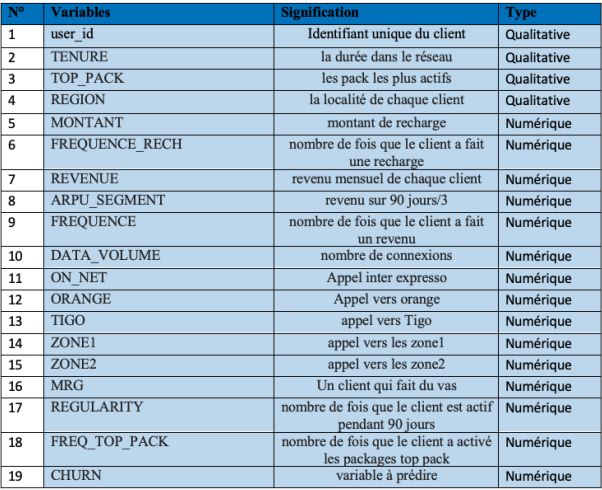

# **2  Méthodologie**
Dans le cadre de cette étude, nous utiliserons la méthodologie du CRISP-DM (CrossIndustry Standard Process for Data Mining). Elle se décompose en 6 étapes allant de la compréhension du problème métier au déploiement et la mise en production


1.   Compréhension du métier

La phase de compréhension du métier consiste à établir clairement le cahier des charges du projet de data mining. Cette phase est réalisée par le maître d’œuvre à partir de la demande du maître d’ouvrage, demande éventuellement exprimée dans un cahier des charges. Elle est l’équivalent de la phase de spécifications fonctionnelles d’un projet de développement informatique. Elle consiste à :


> - Énoncer clairement les objectifs globaux du projet et les contraintes de
l’entreprise.
> - Traduire ces objectifs et ces contraintes en un problème de data mining. Il s’agit donc de formuler une recherche de corrélations, c’est-à-dire la recherche de règles du type : si A alors B



2.   Compréhension des données

Les phases de compréhension et de préparation sont deux phases très importantes d’un projet de data mining. Elles se font en aller-retour. Pour se préparer, il faut comprendre, pour comprendre il faut se préparer. Ces deux phases vont occuper plus de la moitié du temps d’un projet de data mining.
Le principe de la compréhension des données est qu’il faut comprendre toutes les modalités (valeur) des variables (champ ou attribut) sur lesquelles vous travaillez, ce qui passe par l’analyse de la répartition des valeurs de chaque variable, le repérage des valeurs anormales et des valeurs manquantes et l’analyse des corrélations les plus évidentes.

Les étapes de la compréhension des données sont :


> -  Recueillir les données
> - Dictionnaire des variables :
> - Statistiques de base par variable :
> - Suppression de la clé primaire :
> - Nettoyage des données : valeurs manquantes et aberrantes :
> - Corrélations de base entre variables numériques :
> - Corrélations entre variables catégorielles.
> - Corrélations entre variables numériques et variables catégorielles.
> - Corrélations multiples
> - Dernières techniques : discrétisation, variables calculées, sous-ensembles


3.   Préparation des données

Les phases de compréhension et de préparation sont deux phases très importantes
d’un projet de data mining. Elles se font en aller-retour. Pour préparer, il faut comprendre, pour comprendre il faut avoir préparé. Ces deux phases vont occuper plus de la moitié du temps d’un projet de data mining.Fondamentalement, la préparation précède l’analyse exploratoire et les premières recherches de corrélation. La préparation des données consiste à préparer, à partir des données brutes, l’ensemble final des données qui va être utilisé pour toutes les phases suivantes. Cet objectif comporte plusieurs étapes :
>- Fusionner si nécessaire plusieurs tables de données en une seule.
>- Réaliser si nécessaire la suppression de certaines données.
>- Réaliser si nécessaire la correction de certaines données.
>- Réaliser si nécessaire la transformation du type des données
>- Mettre de côté si nécessaire les variables inutiles
>- Créer si nécessaire des variables calculées

4.   Modélisation

La modélisation est généralement effectuée en utilisant plusieurs itérations.
Généralement, les data miners exécutent plusieurs modèles en utilisant les paramètres par défaut, puis affinent ces derniers ou reviennent à la phase de préparation des données pour effectuer les manipulations requises par le modèle de leur choix. Il est rare qu’une question d’exploration de données soit résolue de façon satisfaisante avec un seul modèle et une seule exécution. C’est pourquoi l’exploration de données est si intéressan

5.  Évaluation

A ce stade, la plus grande partie du projet d’exploration de données est réalisée. Vous avez également déterminé, lors de l’étape de modélisation, que les modèles créés sont techniquement corrects et efficaces en fonction des critères de réussite de l’exploration de données définis précédemment.
Néanmoins, avant de poursuivre, vous devez évaluer les résultats de vos efforts en utilisant les critères de réussite commerciale établis au début du projet. Cette étape est primordiale car elle permet de vous assurer que l’entreprise peut utiliser les résultats que vous avez obtenus. L’exploration de données produit deux types de résultat :
> - Les modèles finaux sélectionnés au cours de la phase précédente de CRISP-DM.
> - Les conclusions ou déductions tirées des modèles eux-mêmes, ainsi que du processus d’exploration de données. Elles sont appelées constatations

6.  Déploiement

Le déploiement est le processus consistant à utiliser vos nouvelles connaissances pour apporter des améliorations au sein de l’entreprise. Ceci peut se traduire par une intégration formelle telle que la mise en œuvre d’un modèle produisant des scores d’attrition qui sont ensuite lus dans un entrepôt de données. Le déploiement peut également signifier que vous utilisez les connaissances obtenues suite à l’exploration de données pour provoquer un changement dans votre entreprise. Par exemple, vous avez peut-être découvert des motifs alarmants dans vos données indiquant un changement de comportement des clients âgés de plus de 30 ans. Ces résultats peuvent ne pas être intégrés formellement dans vos systèmes d’informations, mais ils seront sans aucun
doute utiles pour la planification et la prise de décisions marketing.
De façon générale, la phase de déploiement de CRISP-DM comprend deux types d’activité
> - Planification et surveillance du déploiement des résultats
> - Exécution de tâches de synthèse, telles que la production d’un rapport final et la révision du Projet.












# **3  Maitrise des données**

---



>## 3.1 Préliminaires

>>### 3.1.1 Importation des modules et paramétres

In [ ]:
import time
import warnings
import numpy as np
import pandas as pd
#import cleaner as cl
#import plotly.express as px
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.ensemble import ExtraTreesClassifier
from matplotlib import pyplot as plt

In [ ]:
from sklearn.svm import SVC
from sklearn.utils import shuffle
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.compose import make_column_transformer
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, RepeatedStratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import f1_score, recall_score, precision_score, confusion_matrix, classification_report

In [ ]:
#Setup du nombre de lignes et colonnes maximum
pd.set_option('display.max_row',100)
pd.set_option('display.max_columns',34)

#Filtre des avertissements
warnings.filterwarnings('ignore')

#Style et taille de nos figures
plt.style.use(style='ggplot')
plt.rcParams['figure.figsize'] = (12, 8)

#Fixer le générateur
np.random.seed(42)

>>### 3.1.2  Chargement et affichage du jeu de données

- Chargement

In [ ]:
#Chargement de la base de données
from google.colab import files
uploaded=files.upload()

 - Stockage et affichage

In [ ]:
data_frame = pd.read_excel("Base Churn.xlsx")
data_frame

,user_id,REGION,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,MRG,REGULARITY,TOP_PACK,FREQ_TOP_PACK,CHURN
0,00000bfd7d50f01092811bc0c8d7b0d6fe7c3596,FATICK,K > 24 month,4250.0,15.0,4251.0,1417.0,17.0,4.0,388.0,46.0,1.0,1.0,2.0,NO,54,On net 200F=Unlimited _call24H,8.0,0
1,00000cb4a5d760de88fecb38e2f71b7bec52e834,NaN,I 18-21 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,4,NaN,NaN,1
2,00001654a9d9f96303d9969d0a4a851714a4bb57,NaN,K > 24 month,3600.0,2.0,1020.0,340.0,2.0,NaN,90.0,46.0,7.0,NaN,NaN,NO,17,On-net 1000F=10MilF;10d,1.0,0
3,00001dd6fa45f7ba044bd5d84937be464ce78ac2,DAKAR,K > 24 month,13500.0,15.0,13502.0,4501.0,18.0,43804.0,41.0,102.0,2.0,NaN,NaN,NO,62,"Data:1000F=5GB,7d",11.0,0
4,000028d9e13a595abe061f9b58f3d76ab907850f,DAKAR,K > 24 month,1000.0,1.0,985.0,328.0,1.0,NaN,39.0,24.0,NaN,NaN,NaN,NO,11,Mixt 250F=Unlimited_call24H,2.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1048570,7cb5a227517f04b2d30f40e80b8207957fba7761,SAINT-LOUIS,K > 24 month,9000.0,17.0,9000.0,3000.0,16.0,0.0,344.0,181.0,NaN,1.0,NaN,NO,56,MIXT:500F= 2500F on net _2500F off net;2d,9.0,0
1048571,7cb5a30c0494d3f3c17675ceff78970d4e83748a,NaN,K > 24 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,2,NaN,NaN,1
1048572,7cb5aca1f1be878196785b9041b2d0acd85c3280,KAFFRINE,K > 24 month,10000.0,10.0,10004.0,3335.0,16.0,25542.0,22.0,58.0,1.0,NaN,NaN,NO,62,"Data:1000F=2GB,30d",10.0,0
1048573,7cb5c3d45abd64d3b13ded0bd60804e130a54cb6,DIOURBEL,K > 24 month,1000.0,1.0,984.0,328.0,2.0,5.0,6.0,1.0,NaN,NaN,NaN,NO,8,IVR Echat_Daily_50F,2.0,0


In [ ]:
# affichage des 10 premiers enregistrements
data_frame.head(10)

,user_id,REGION,TENURE,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,MRG,REGULARITY,TOP_PACK,FREQ_TOP_PACK,CHURN
0,00000bfd7d50f01092811bc0c8d7b0d6fe7c3596,FATICK,K > 24 month,4250.0,15.0,4251.0,1417.0,17.0,4.0,388.0,46.0,1.0,1.0,2.0,NO,54,On net 200F=Unlimited _call24H,8.0,0
1,00000cb4a5d760de88fecb38e2f71b7bec52e834,NaN,I 18-21 month,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO,4,NaN,NaN,1
2,00001654a9d9f96303d9969d0a4a851714a4bb57,NaN,K > 24 month,3600.0,2.0,1020.0,340.0,2.0,NaN,90.0,46.0,7.0,NaN,NaN,NO,17,On-net 1000F=10MilF;10d,1.0,0
3,00001dd6fa45f7ba044bd5d84937be464ce78ac2,DAKAR,K > 24 month,13500.0,15.0,13502.0,4501.0,18.0,43804.0,41.0,102.0,2.0,NaN,NaN,NO,62,"Data:1000F=5GB,7d",11.0,0
4,000028d9e13a595abe061f9b58f3d76ab907850f,DAKAR,K > 24 month,1000.0,1.0,985.0,328.0,1.0,NaN,39.0,24.0,NaN,NaN,NaN,NO,11,Mixt 250F=Unlimited_call24H,2.0,0


>## 3.2 Analyse exploiratoire des données


**NB** :  Dans le souci  de conserver l'authenticité des données nous allons travailler sur une copie des données

In [ ]:
# Base de données copie
copy_data=data_frame.copy()

>>#### 3.2.1  Proprietées du jeu de données

> - dimension

In [ ]:
print("Nombres d'enregistements : {} ".format(data_frame.shape[0]))
print("Nombres de colonnes (variables) : {} ".format(data_frame.shape[1]))

Nombres d'enregistements : 1048575 
Nombres de colonnes (variables) : 19 


> - Target

In [ ]:
# catégorie
copy_data['CHURN'].value_counts()

0    851776
1    196799
Name: CHURN, dtype: int64

> La variable CHURN contient deux catégories numérique (0,1) .Nous allons procéder à son encodage initial afin de mieux voir l'information contenu dans celle ci

In [ ]:
# Encodage initial de la target
copy_data['CHURN']=copy_data['CHURN'].replace([0,1],['Loyal','Désabonné(e)'])

In [ ]:
# répartition en Pourcentage de la  varaibale CHURN
print("répartition en Pourcentage de la variable CHURN")
copy_data['CHURN'].value_counts(normalize=TRUE)*100

répartition en Pourcentage de la variable CHURN


Loyal           81.231767
Désabonné(e)    18.768233
Name: CHURN, dtype: float64

> - Type de variable

In [ ]:
# type à l'entré
data_frame.dtypes.value_counts()

float64    12
object      5
int64       2
dtype: int64

In [ ]:
# Varible Qualitatives
variables_qualitatives=[i for i in copy_data.select_dtypes(include = 'object')]
print("Liste des variable qualitatives : ")
for i in variables_qualitatives :
  print(i)
print("TOTAL : {} ".format(len(variables_qualitatives)))

Liste des variable qualitatives : 
user_id
REGION
TENURE
MRG
TOP_PACK
TOTAL : 5 


In [ ]:
# Varible Quantitatives
variables_quantitatives=[i for i in copy_data.select_dtypes(exclude = 'object')]
print("Liste des variables quantitatives : ")
for i in variables_quantitatives :
  print(i)
print("TOTAL : {} ".format(len(variables_quantitatives)))

Liste des variables quantitatives : 
MONTANT
FREQUENCE_RECH
REVENUE
ARPU_SEGMENT
FREQUENCE
DATA_VOLUME
ON_NET
ORANGE
TIGO
ZONE1
ZONE2
REGULARITY
FREQ_TOP_PACK
CHURN
TOTAL : 14 


>>### 3.2.2 Analyse univariré


L’analyse univariée a pour but de décrire et mesurer la répartition des valeurs que peut prendre une variable.

>>>#### 3.2.2.1 Audit complet  des données

In [ ]:
# Suppression de la cles primaire
copy_data=copy_data.drop(columns='user_id',axis=1)

In [ ]:
# Reinitialisation de la liste
variables_qualitatives=[i for i in copy_data.select_dtypes(include = 'object')]

**Variables qualitatives**

> - Statistique de base

In [ ]:
# Summmary
copy_data[variables_qualitatives].describe()

,REGION,TENURE,MRG,TOP_PACK,CHURN
count,635141,1048575,1048575,609188,1048575
unique,14,8,1,126,2
top,DAKAR,K > 24 month,NO,All-net 500F=2000F;5d,Loyal
freq,249806,994587,1048575,154760,851776


> - Distribution

Distribution des variables qualitatives


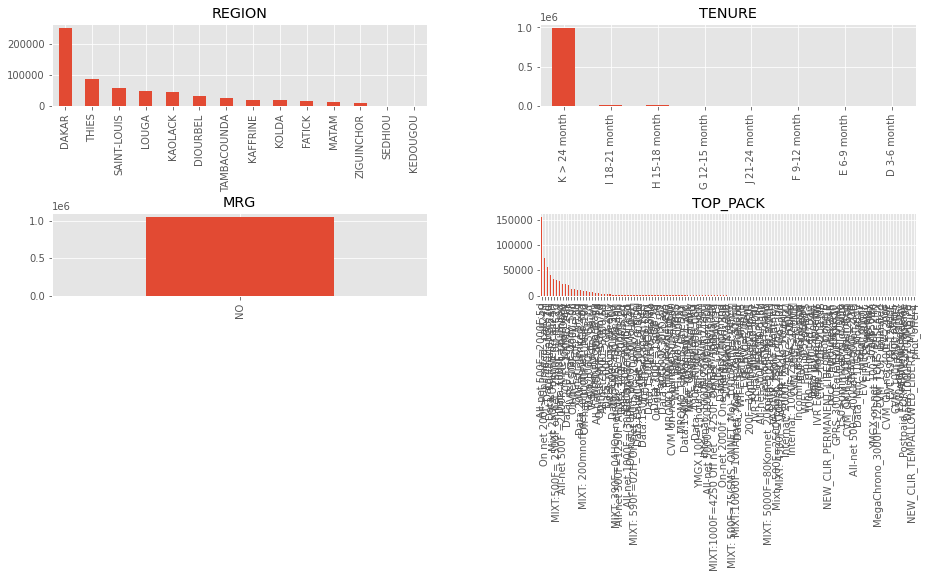

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
print("Distribution des variables qualitatives")
plt.figure(figsize=(15,8))
i=1
for var in variables_qualitatives :
  plt.subplot(3,2,i)
  copy_data[var].value_counts().plot.bar()
  plt.title(var)
  plt.subplots_adjust(left=0.1,
                    bottom=0.2,
                    right=0.9,
                    top=1,
                    wspace=0.3,
                    hspace=1.3)
  i+=1

> La variable CHURN contient deux catégories numérique (0,1) .Nous allons procéder à son encodage initial afin de mieux voir  L’information contenue dans celle ci

**Variables quantitatives**

> - Statistique de base

In [ ]:
# Summary
copy_data[variables_quantitatives].describe()

,MONTANT,FREQUENCE_RECH,REVENUE,ARPU_SEGMENT,FREQUENCE,DATA_VOLUME,ON_NET,ORANGE,TIGO,ZONE1,ZONE2,REGULARITY,FREQ_TOP_PACK
count,679931.000000,679931.000000,694797.000000,694797.000000,694797.000000,5.320410e+05,665211.000000,612535.000000,420459.000000,82630.000000,66343.000000,1.048575e+06,609188.000000
mean,5538.217109,11.541451,5514.798879,1838.272454,13.990561,3.367127e+03,277.695893,95.639485,23.038808,8.100629,7.390456,2.803957e+01,9.279864
std,7147.712610,13.282298,7199.856252,2399.947652,14.698701,1.322715e+04,873.530717,207.059750,62.597335,43.353739,31.206813,2.229285e+01,12.362366
min,10.000000,1.000000,1.000000,0.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,1.000000
25%,1000.000000,2.000000,1000.000000,333.000000,3.000000,0.000000e+00,5.000000,7.000000,2.000000,0.000000,0.000000,6.000000e+00,2.000000
50%,3000.000000,7.000000,3000.000000,1000.000000,9.000000,2.600000e+02,27.000000,29.000000,6.000000,1.000000,2.000000,2.400000e+01,5.000000
75%,7350.000000,16.000000,7387.000000,2462.000000,20.000000,2.888000e+03,157.000000,99.000000,20.000000,3.000000,5.000000,5.100000e+01,12.000000
max,470000.000000,133.000000,532177.000000,177392.000000,91.000000,1.556829e+06,50809.000000,21323.000000,3728.000000,4792.000000,2008.000000,6.200000e+01,713.000000


> - Distribution

Distribution des variables quantitatives


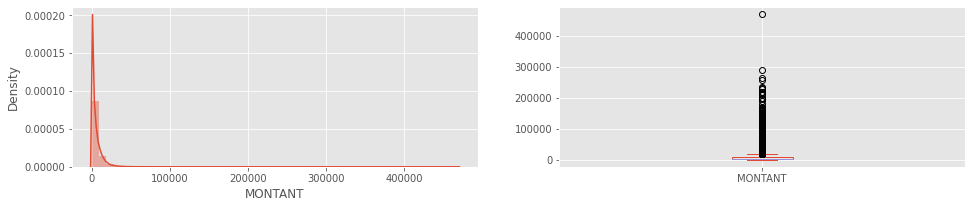

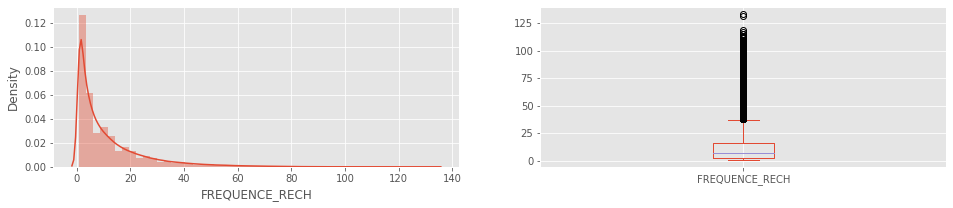

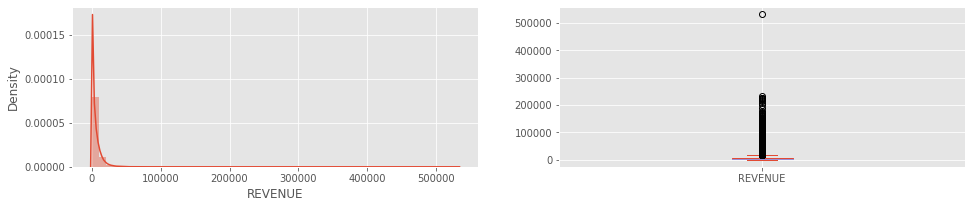

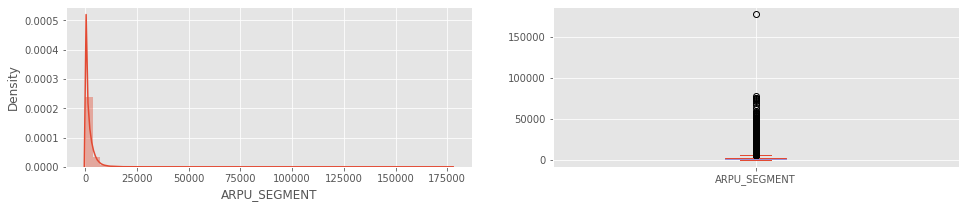

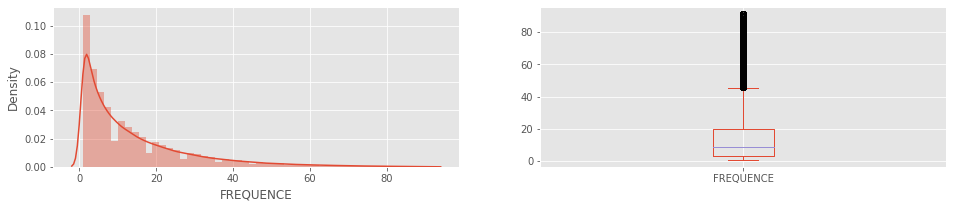

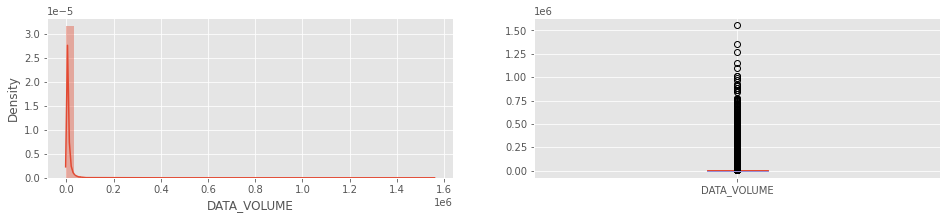

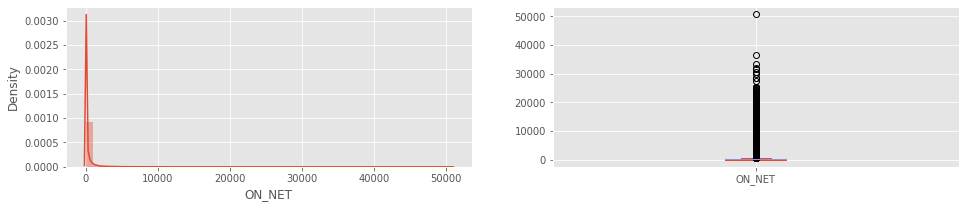

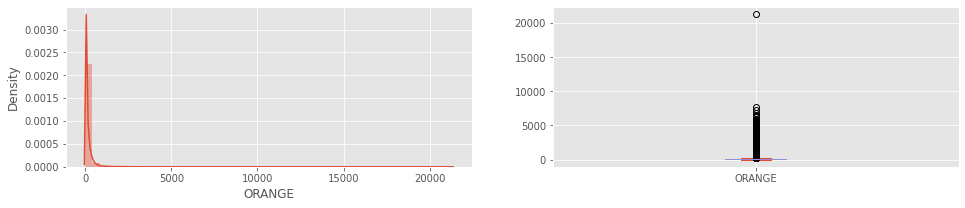

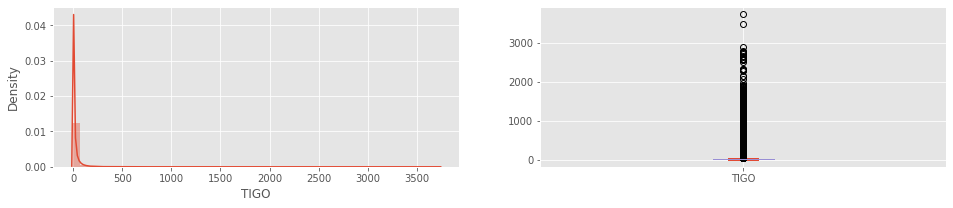

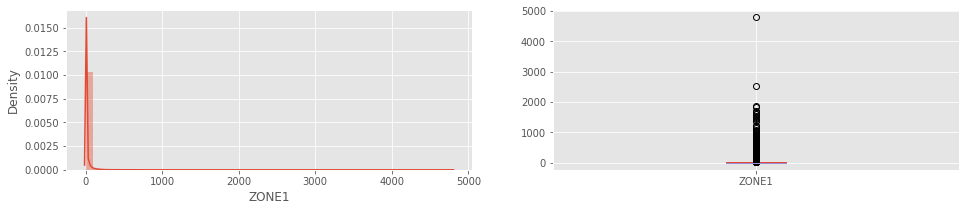

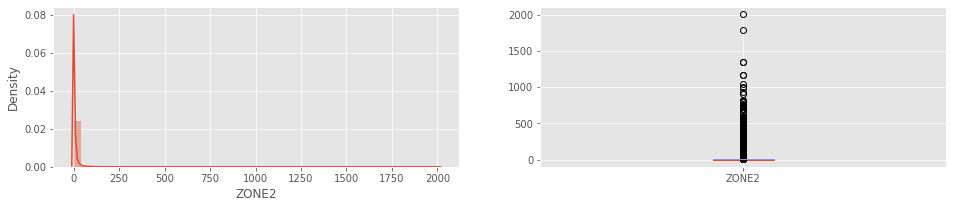

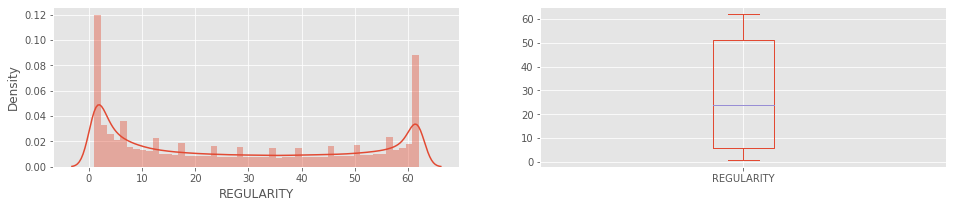

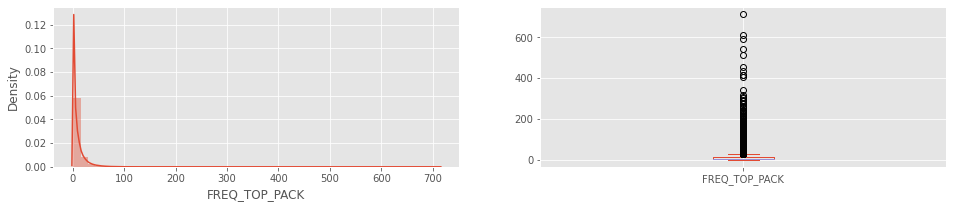

In [ ]:
# Distribution des variables qualitatives
from matplotlib import pyplot as plt
import seaborn as sns
print("Distribution des variables quantitatives")
i=1
for var in variables_quantitatives :
  plt.figure(figsize=(1,0.5))
  plt.subplot(3,2,1)
  sns.distplot(copy_data[var])

  plt.subplot(3,2,2)
  copy_data[var].plot.box(figsize=(16,10))
  plt.suptitle('')
  plt.show()

> Nous remarquons que la quasi-totalité des variables a une distribution asymétrique vers la gauche avec un nombre de valeurs manquantes assez élevé

>>>#### 3.2.2.2 Distrubition de la variable CHURN


Text(0.5, 0, 'CHURN')

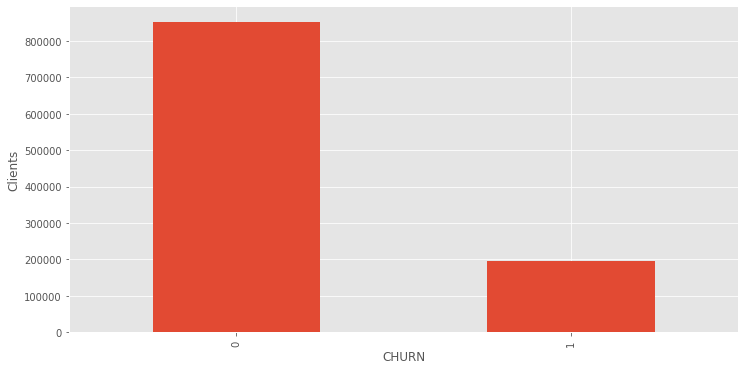

In [ ]:
plt.figure(figsize=(12,6))
copy_data['CHURN'].value_counts().plot.bar()
plt.ylabel("Clients")
plt.xlabel("CHURN")

>***Commentaire*** : A travers ce graphique qui illustre la distribution de la variable churn nous constatons que le jeu de données est déséquilibré confirmant le pourcentage de désabonnement détecté au préalable

>>>#### 3.2.2.3 Distribution de la variable REVENUE

Text(0, 0.5, 'Clients')

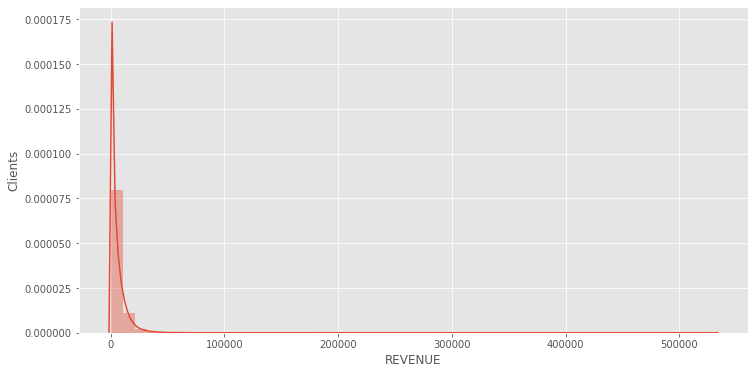

In [ ]:
plt.figure(figsize=(12,6))
sns.distplot(copy_data['REVENUE'])
plt.ylabel("Clients")


>***Commentaire*** : Ce graphique montre que le que la majorité des clients ont un niveau de
revenu faible.

>>>#### 3.2.2.4 Distrubiton du Montant

<AxesSubplot:xlabel='MONTANT', ylabel='Density'>

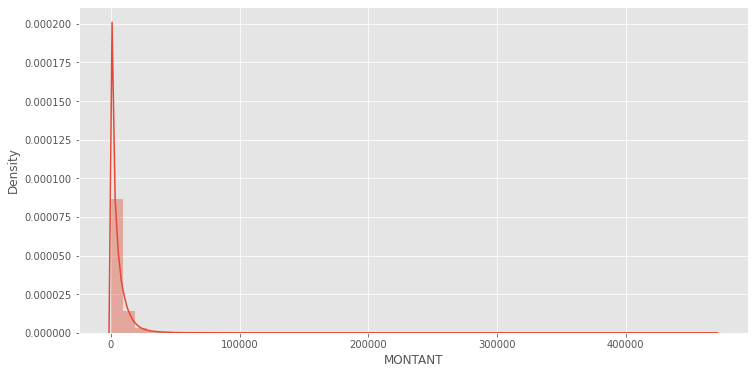

In [ ]:
plt.figure(figsize=(12,6))
sns.distplot(copy_data['MONTANT'])


>***Commentaire*** :  Cette	 représentation	 nous	 informe	 sur	 le	 fait	 que	 la	 majorité des	 clients	présente	un	niveau	de	montant de recharge	assez	bas.

>>>#### 3.2.2.5 Distribution du DATA_VOLUME

<AxesSubplot:xlabel='DATA_VOLUME', ylabel='Density'>

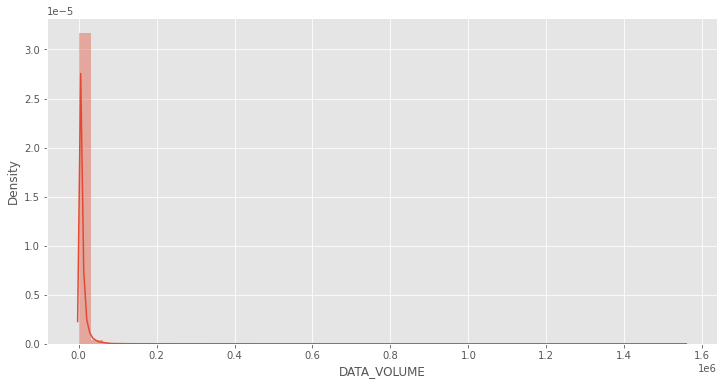

In [ ]:
plt.figure(figsize=(12,6))
sns.distplot(copy_data['DATA_VOLUME'])

>***Commentaire*** : De	même	au	niveau	de	cette	représentation	nous	remarquons	que	la	plupart	des	clients	effectuent une	consommation	très	basse	des	volumes de	données.

>>>####  3.2.2.6 Analyse des valeurs manquantes





Text(0.5, 1.0, 'Valeurs manquantes')

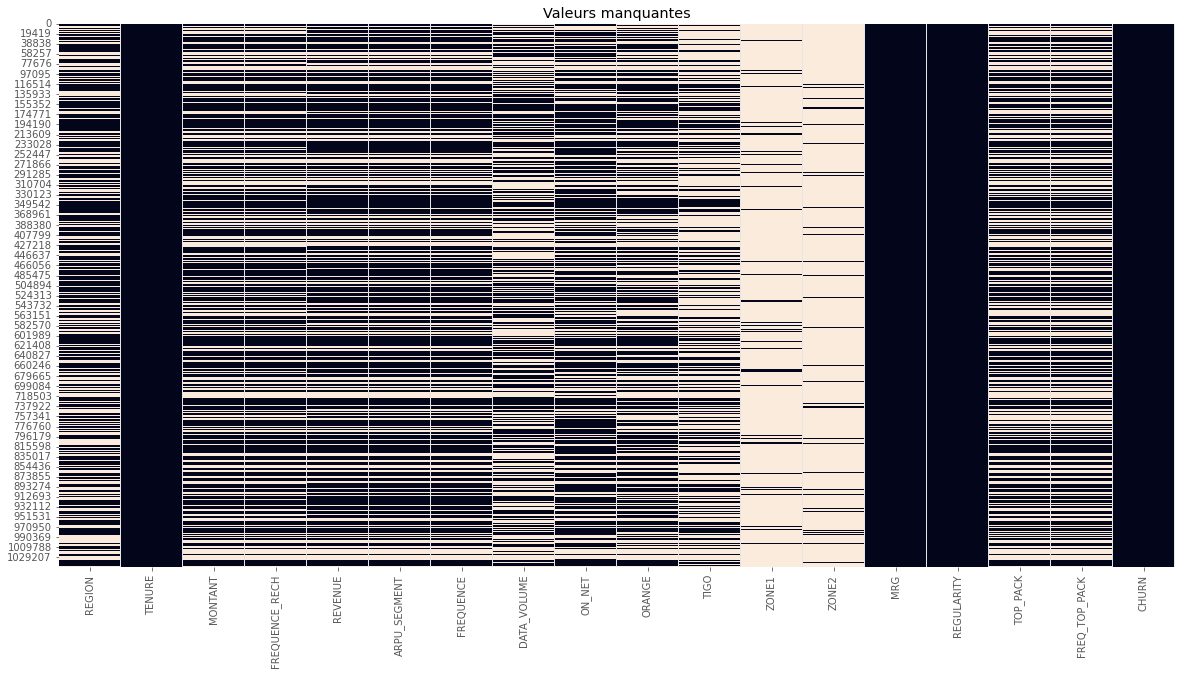

In [ ]:
# visualisation des valeurs manquantes
plt.figure(figsize=(20,10))
sns.heatmap(copy_data.isna(),cbar=False).set_title("Valeurs manquantes")

>***Commentaire*** : Ce graphe nous revelle qu'il y a beaucoup de données manquantes notemmment au niveau des variables ZONE1 et ZONE2.

In [ ]:
print("Pourcentage de valeurs manquantes des variables :")
((copy_data.isna().sum()/copy_data.shape[0])*100).sort_values()

Pourcentage de valeurs manquantes des variables :


CHURN              0.000000
TENURE             0.000000
REGULARITY         0.000000
MRG                0.000000
REVENUE           33.738931
ARPU_SEGMENT      33.738931
FREQUENCE         33.738931
MONTANT           35.156665
FREQUENCE_RECH    35.156665
ON_NET            36.560475
REGION            39.428176
ORANGE            41.584055
FREQ_TOP_PACK     41.903250
TOP_PACK          41.903250
DATA_VOLUME       49.260568
TIGO              59.901867
ZONE1             92.119782
ZONE2             93.673032
dtype: float64

>***Commentaire*** : Nous remarquons que seul es variables MRG , CHURN et REVENUE ne présentent pas de valeurs manquantes

**Suppression et imputation des valeurs manquantes**

In [ ]:
#Suppression des colonnes ayant plus de 50% de valeurs manquantes
copy_data=copy_data[copy_data.columns[copy_data.isna().sum()/copy_data.shape[0] < 0.5]]

In [ ]:
# Suppression des lignes contenant des valeurs manquantes par rapport au colonnes
copy_data=copy_data.dropna(subset=["REVENUE",'MONTANT','FREQUENCE_RECH',"TOP_PACK","FREQ_TOP_PACK"])

In [ ]:
# Imputation des variables ON_NET et ORANGE par la median
copy_data['ON_NET'].fillna(copy_data['ON_NET'].median(),inplace=True)
copy_data['ORANGE'].fillna(copy_data['ORANGE'].median(),inplace=True)
copy_data['DATA_VOLUME'].fillna(copy_data['DATA_VOLUME'].median(),inplace=True)

In [ ]:
#Imputation de la variable REGION par la valeur précédente
copy_data['REGION'].fillna(method='ffill',inplace=True)

>>### 3.2.3 Analyse bivariée

>>>#### 3.2.3.1 Visualisation de la pertinence des variables par rapport à la variable CHURN

Text(0.5, 1.0, "Le churn est-il corole à l'ancienneté ? \n")

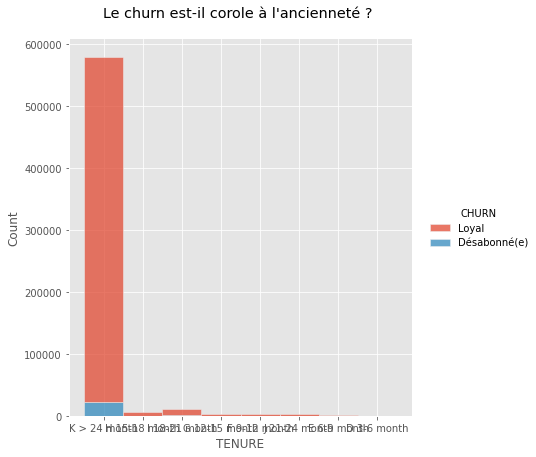

In [ ]:
sns.displot(data=copy_data, x="TENURE", hue="CHURN", multiple="stack",height=6,weights=1)
plt.title("Le churn est-il corole à l'ancienneté ? \n")

>***Commentaire*** : Le phénomène du churn est plus observé chez les abonnés avec une
ancienneté de plus de 24 mois dans le réseau.

Text(0.5, 1.0, 'Le churn est-il lié au revenue du client ? \n')

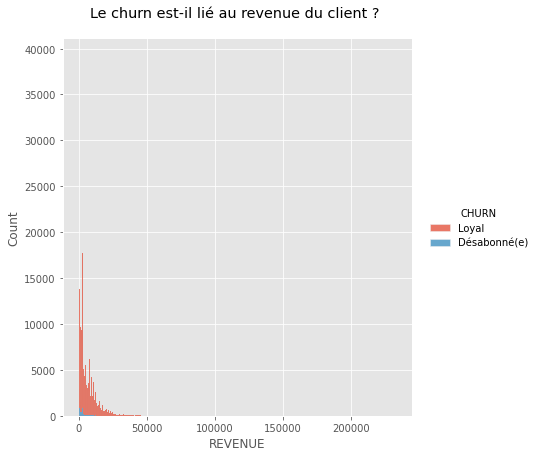

In [ ]:
sns.displot(data=copy_data, x="REVENUE", hue="CHURN", multiple="stack",height=6)
plt.title("Le churn est-il lié au revenue du client ? \n")

>***Commentaire*** : Ce graphique montre que le phénomène du churn est plus observer chez
les clients à faible fréquence de recharge.

Text(0.5, 1.0, 'La fréquence de recharge explique-t-elle le churn ? \n')

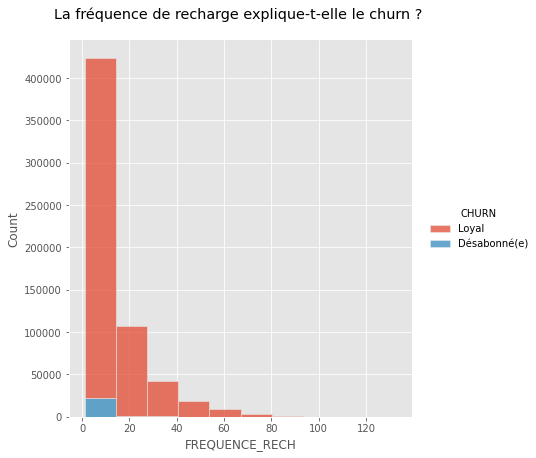

In [ ]:
sns.displot(data=copy_data, x="FREQUENCE_RECH", hue="CHURN", multiple="stack",height=6,weights=1)
plt.title("La fréquence de recharge explique-t-elle le churn ? \n")

>***Commentaire*** : Ce graphique montre que le phénomène du churn est plus en évidence chez
les clients à faible fréquence de recharge.

Text(0.5, 1.0, 'Le churn est-il lié au montant de recharge du client ? \n')

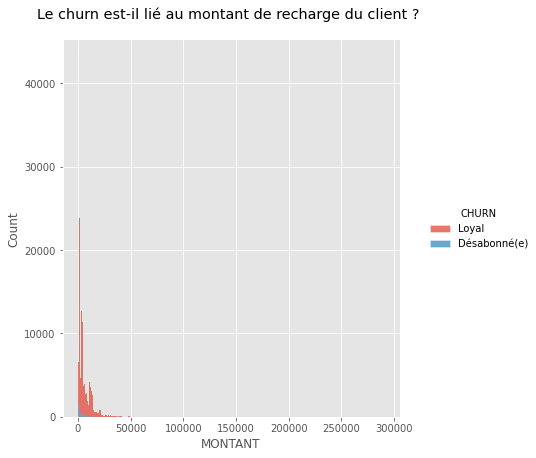

In [ ]:
sns.displot(data=copy_data, x="MONTANT", hue="CHURN", multiple="stack",height=6)
plt.title("Le churn est-il lié au montant de recharge du client ? \n")

>***Commentaire***: Ce graphique montre que le phénomène du churn est plus observé chez les
abonnés à faible revenu

Text(0.5, 1.0, 'La régularité du client peut-il expliqué le CHURN ? \n')

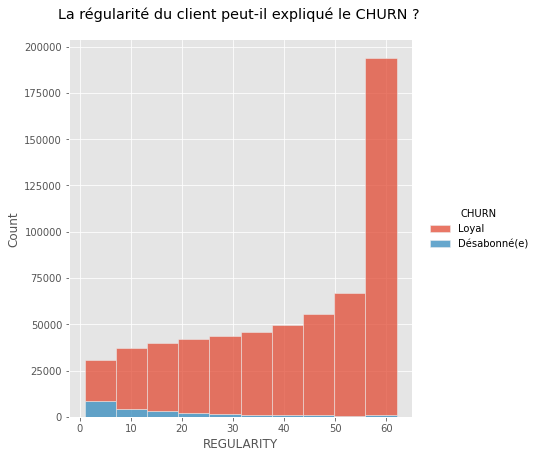

In [ ]:
sns.displot(data=copy_data, x="REGULARITY", hue="CHURN", multiple="stack",height=6,weights=1)
plt.title("La régularité du client peut-il expliqué le CHURN ? \n")

>***Commentaire*** : Cette représentation nous informe sur le fait que le phénomène du Churn se
manifeste au niveau des clients dont le nombre de fois qu’ils ont été actifs pendant 90 jours
est faible

Text(0.5, 1.0, 'Le volume de donnée explique-t-il le CHURN ? \n')

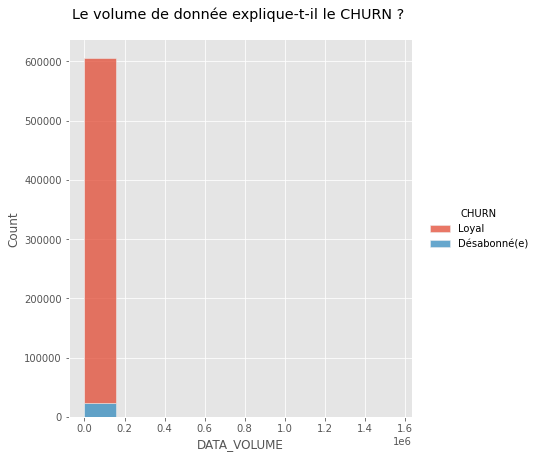

In [ ]:
sns.displot(data=copy_data, x="DATA_VOLUME", hue="CHURN", multiple="stack",height=6,weights=1)
plt.title("Le volume de donnée explique-t-il le CHURN ? \n")

***Commentaire*** : Ce graphique montre que le phénomène du churn est plus observé chez les
abonnés qui utilisent moins de données mobiles.

Text(0.5, 1.0, 'Le nombre de fois qu’un client a effectué des appels vers l’opérateur Orange est-il lié au CHURN ?\n ')

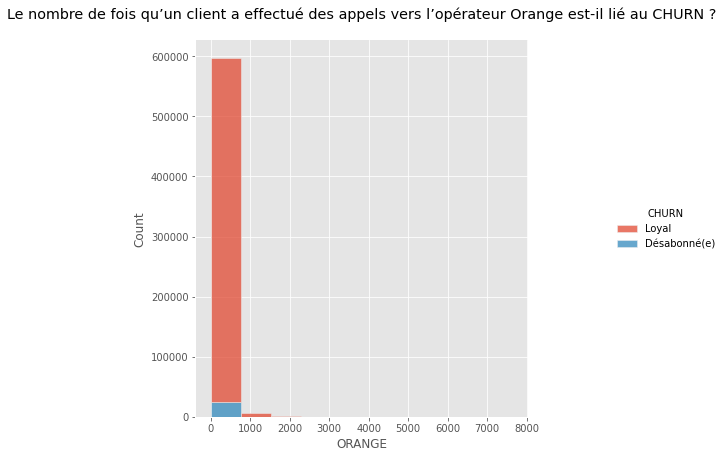

In [ ]:
sns.displot(data=copy_data, x="ORANGE", hue="CHURN", multiple="stack",height=6,weights=1)
plt.title("Le nombre de fois qu’un client a effectué des appels vers l’opérateur Orange est-il lié au CHURN ?\n ")

***Commentaire*** : Le phénomène du churn est plus observé chez les abonnés ayant effectué le
plus grand nombre d’appels vers le réseaux orange.

>>>#### 3.2.3.2 Test de corrélations entre variables numériques

Trouver une corrélation entre deux variables numériques consiste à trouver l’équation de la courbe qui relie toutes les données entre elles quand les variables sont classées en ordre croissant. La corrélation linéaire correspond à l’équation la plus simple : une équation de droite du type : ax + b = Y

In [ ]:
#Définition d'une fonction de test entre variables quantitatives
def test_pearson(df, var1, var2):
    print("{} et {}".format(var1,var2))
    print("Coefficient de Pearson : {}".format(pearsonr(df[var1],df[var2])[0]))
    print("               P_value : {}".format(pearsonr(df[var1],df[var2])[1]))
    if (pearsonr(df[var1],df[var2])[1] < 0.05):
        print("{} et {} ne sont pas indépendantes".format(var1,var2))
    else:
        print("{} et {} sont indépendantes".format(var1,var2))
    print("\n \n")
    pass

In [ ]:
# reinitialisation
variables_quantitatives=[i for i in copy_data.select_dtypes(exclude = 'object')]

In [ ]:
#test d'indépendence entre toutes les variables numériques
#Test Statistique de Pearson
from scipy.stats import pearsonr
for var1 in variables_quantitatives:
    liste=[var1]
    #liste.append(var1)
    for var2 in [var for var in variables_quantitatives if var not in liste ]:
        test_pearson(copy_data,var1,var2)

MONTANT et FREQUENCE_RECH
Coefficient de Pearson : 0.7885558148681624
               P_value : 0.0
MONTANT et FREQUENCE_RECH ne sont pas indépendantes

 

MONTANT et REVENUE
Coefficient de Pearson : 0.9818377424445074
               P_value : 0.0
MONTANT et REVENUE ne sont pas indépendantes

 

MONTANT et ARPU_SEGMENT
Coefficient de Pearson : 0.9818376780841023
               P_value : 0.0
MONTANT et ARPU_SEGMENT ne sont pas indépendantes

 

MONTANT et FREQUENCE
Coefficient de Pearson : 0.7729021637425973
               P_value : 0.0
MONTANT et FREQUENCE ne sont pas indépendantes

 

MONTANT et DATA_VOLUME
Coefficient de Pearson : 0.2519615362776122
               P_value : 0.0
MONTANT et DATA_VOLUME ne sont pas indépendantes

 

MONTANT et ON_NET
Coefficient de Pearson : 0.3243871829646505
               P_value : 0.0
MONTANT et ON_NET ne sont pas indépendantes

 

MONTANT et ORANGE
Coefficient de Pearson : 0.6532322770532246
               P_value : 0.0
MONTANT et ORANGE ne sont pas

Nous constatons que toutes nos variables sont corréler, nous allons retenir une des variables pour chaque couple de variable corrélé

>>>#### 3.2.3.3 Test de corrélations entre variables qualitatives

Le même principe que pour les variables numériques : croiser chaque variable catégorielle avec toutes les autres variables catégorielles

In [ ]:
#Définition d'une fonction de test entre variables qualitatives
def test_khi2(df, var1, var2):
    table = pd.crosstab(df[var1],df[var2])
    resultats = chi2_contingency(table)
    print("{} et {}".format(var1,var2))
    print("Statistique de test : {}".format(resultats[0]))
    print("   Degré de liberté : {}".format(resultats[2]))
    print("            P_value : {}".format(resultats[1]))
    if ( resultats[1] < 0.05):
        print("{} et {} ne sont pas indépendantes".format(var1,var2))
    else:
        print("{} et {} sont indépendantes".format(var1,var2))
    print("\n \n")
    pass

In [ ]:
#Test Statistique du Khi-deux
qual_cols=['REGION', 'TENURE','CHURN', 'MRG','TOP_PACK']
from scipy.stats import chi2_contingency
liste = []
for var1 in qual_cols:
    liste.append(var1)
    for var2 in [var for var in qual_cols if var not in liste ]:
        test_khi2(copy_data,var1,var2)

REGION et TENURE
Statistique de test : 1193.781962565909
   Degré de liberté : 91
            P_value : 1.2146604286933102e-191
REGION et TENURE ne sont pas indépendantes

 

REGION et CHURN
Statistique de test : 52.45230491093833
   Degré de liberté : 13
            P_value : 1.1251215432679889e-06
REGION et CHURN ne sont pas indépendantes

 

REGION et MRG
Statistique de test : 0.0
   Degré de liberté : 0
            P_value : 1.0
REGION et MRG sont indépendantes

 

REGION et TOP_PACK
Statistique de test : 60875.46048096362
   Degré de liberté : 1612
            P_value : 0.0
REGION et TOP_PACK ne sont pas indépendantes

 

TENURE et CHURN
Statistique de test : 285.73908556258334
   Degré de liberté : 7
            P_value : 6.697786787412698e-58
TENURE et CHURN ne sont pas indépendantes

 

TENURE et MRG
Statistique de test : 0.0
   Degré de liberté : 0
            P_value : 1.0
TENURE et MRG sont indépendantes

 

TENURE et TOP_PACK
Statistique de test : 9922.549495405212
   Degré

Nous constatons que la variable PRG n'est pas corrélé à la variable ,donc ne peut pas expliquer le churn

>>> #### 3.2.3.4 Test de corrélations entre variables qualitatives et variables quantitatives

Toujours dans l'optique d'éviter les effets de rédondances, nous allons étudier en dernier les relations entre variables indépendantes qualitatives et quantitatives. L'ANOVA est alors nécessaire pour une telle étude.



In [ ]:
#Définition d'une fonction de test entre variables qualitative et quantitative
def test_anova(df, var1, var2):
    results = statsmodels.formula.api.ols('{} ~ {}'.format(var1,var2), data = df).fit()
    table = statsmodels.api.stats.anova_lm(results)
    print("{} et {}".format(var1,var2))
    print("Statistique de test : {}".format(table['F'][0]))
    print("   Degré de liberté : {}".format(table['df'][0]))
    print("            P_value : {}".format(table['PR(>F)'][0]))
    if ( table['PR(>F)'][0] < 0.05):
        print("{} et {} ne sont pas indépendantes".format(var1,var2))
    print("\n \n")
    pass

In [ ]:
#ANOVA
qual_cols=['REGION', 'TENURE','TOP_PACK']
variables=['MONTANT','REVENUE','REGULARITY']
from scipy.stats import chi2_contingency
liste = []
for var1 in qual_cols:
    liste.append(var1)
    for var2 in [var for var in variables if var not in liste ]:
        test_khi2(copy_data,var1,var2)

REGION et MONTANT
Statistique de test : 66325.26126242153
   Degré de liberté : 54106
            P_value : 1.107483221568161e-263
REGION et MONTANT ne sont pas indépendantes

 

REGION et REVENUE
Statistique de test : 348950.991356141
   Degré de liberté : 408772
            P_value : 1.0
REGION et REVENUE sont indépendantes

 

REGION et REGULARITY
Statistique de test : 3989.2788683984513
   Degré de liberté : 793
            P_value : 0.0
REGION et REGULARITY ne sont pas indépendantes

 

TENURE et MONTANT
Statistique de test : 28530.49022650802
   Degré de liberté : 29134
            P_value : 0.9940463045138647
TENURE et MONTANT sont indépendantes

 

TENURE et REVENUE
Statistique de test : 219777.88435591265
   Degré de liberté : 220108
            P_value : 0.6903314216810895
TENURE et REVENUE sont indépendantes

 

TENURE et REGULARITY
Statistique de test : 848.0120461488048
   Degré de liberté : 427
            P_value : 4.304990691438585e-30
TENURE et REGULARITY ne sont pas i

>>### 3.2.4 Analyse multivariée

Text(0.5, 1.0, 'Diagramme de dispersion du churn (2D) suivant le revenu et le volume de données \n')

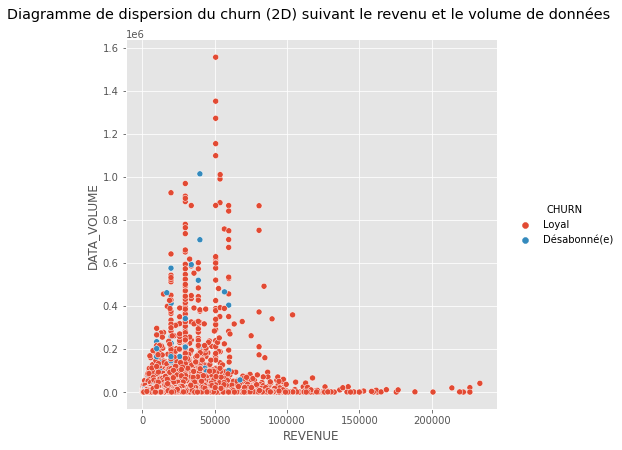

In [ ]:
sns.pairplot(copy_data,x_vars='REVENUE',y_vars='DATA_VOLUME',hue='CHURN',height=6)
plt.title("Diagramme de dispersion du churn (2D) suivant le revenu et le volume de données \n")

***Commentaire*** : Ce diagramme confirme les deux visuels précédents à savoir que l’attrition est
plus observée chez les abonnés à faible revenu et utilisant moins de données mobiles.

#  **4 Modélisation**

>## 4.1 Prétraitement des données

>>### 4.1.1 Préselection des variables

In [ ]:
df=copy_data.drop(columns=['MRG','TOP_PACK','ON_NET','ARPU_SEGMENT','REGION','TENURE','FREQUENCE'],axis= 1)

>>### 4.1.2 Encodage

In [ ]:
df['CHURN']=df['CHURN'].replace(['Loyal','Désabonné(e)'],[0,1])

>>### 4.1.3 Subdivision de la base en Train / Test

Nous allons maintenant divisé nos données en deux sous ensemble , une pour l'apprentissage et une pour le test



In [ ]:
#Affectation de la matrice de variables explicatives à X et de la target à y
X = df.drop('CHURN', axis = 1)
y = df['CHURN']  # Series plutôt que DataFrame à une colonne

# stratify=y : conserve la proportion de churn (~19%) dans train ET test
# random_state=42 : rend le split reproductible d'une exécution à l'autre
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [ ]:
print("Dimensions X_train :", X_train.shape)
print("Dimensions y_train :", y_train.shape)
print("Dimensions X_test :", X_test.shape)
print("Dimensions y_test :", y_test.shape)

Dimensions X_train : (423913, 7)
Dimensions y_train : (423913, 1)
Dimensions X_test : (181678, 7)
Dimensions y_test : (181678, 1)


>## 4.2 Construction et évaluation du Modél

- Construction

**⚠️ Point important avant de modéliser** : la variable CHURN est déséquilibrée (~81% de clients loyaux / ~19% de désabonnés, voir section 3.2.2.2). Dans ce contexte, l'**accuracy** — et le **F1-score en moyenne `micro`**, qui lui est mathématiquement équivalent — peuvent donner une impression de performance trompeuse : un modèle qui prédit toujours "Loyal" obtient déjà ~81% d'accuracy sans aucune valeur prédictive. Nous allons donc comparer plusieurs modèles avec des métriques adaptées au déséquilibre (**ROC-AUC**, **Average Precision / PR-AUC**, **F1-macro**), plutôt que de nous fier à un seul indicateur global.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    f1_score, precision_score, recall_score,
)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn import tree
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

### 4.2.1 Comparaison de plusieurs modèles par validation croisée

In [ ]:
# Imputation de sécurité : au cas où des valeurs manquantes subsisteraient
# dans les colonnes conservées (seules celles à plus de 50% de valeurs
# manquantes ont été supprimées en 3.2.2.6, pas forcément toutes les NaN).
imputer = SimpleImputer(strategy="median")

# class_weight="balanced" : compense le déséquilibre des classes au niveau
# de l'algorithme plutôt que de laisser le modèle ignorer la classe minoritaire.
models = {
    "Régression logistique": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Arbre de décision": DecisionTreeClassifier(max_depth=6, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
}

# NB : cv=3 plutôt que 5, et un sous-échantillon pour la comparaison,
# pour garder des temps de calcul raisonnables vu la taille du jeu de données
# (~1M lignes). Le modèle final sera ré-entraîné sur X_train en entier.
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
scoring = {"roc_auc": "roc_auc", "avg_precision": "average_precision", "f1_macro": "f1_macro"}

X_cv, _, y_cv, _ = train_test_split(
    X_train, y_train, train_size=0.3, stratify=y_train, random_state=RANDOM_STATE
)

results = []
for name, model in models.items():
    pipeline = Pipeline([("impute", imputer), ("model", model)])
    scores = cross_validate(pipeline, X_cv, y_cv, cv=cv, scoring=scoring, n_jobs=-1)
    results.append({
        "Modèle": name,
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "PR-AUC (Average Precision)": scores["test_avg_precision"].mean(),
        "F1-macro": scores["test_f1_macro"].mean(),
    })

results_df = pd.DataFrame(results).set_index("Modèle")
results_df.style.format("{:.3f}").background_gradient(cmap="Greens")

In [ ]:
results_df.plot.bar(figsize=(9, 5), rot=0)
plt.title("Comparaison des modèles — validation croisée (échantillon du train set)")
plt.ylabel("Score")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 4.2.2 Optimisation d'hyperparamètres

Le notebook original importait `GridSearchCV` / `RandomizedSearchCV` sans jamais les utiliser. Nous optimisons ici un **Random Forest** — un choix robuste et peu sensible au bruit pour des données tabulaires — via une recherche aléatoire d'hyperparamètres.

In [ ]:
param_distributions = {
    "model__n_estimators": [150, 250, 350],
    "model__max_depth": [8, 12, 16, None],
    "model__min_samples_leaf": [1, 5, 10],
    "model__max_features": ["sqrt", "log2"],
}

rf_pipeline = Pipeline([
    ("impute", imputer),
    ("model", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
])

search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_distributions,
    n_iter=8,
    scoring="average_precision",
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
search.fit(X_cv, y_cv)

print("Meilleurs hyperparamètres :")
for k, v in search.best_params_.items():
    print(f"  {k.replace('model__', '')}: {v}")
print(f"\nMeilleur score PR-AUC (validation croisée) : {search.best_score_:.3f}")

# Ré-entraînement du meilleur modèle sur l'intégralité du train set
best_model = search.best_estimator_
best_model.fit(X_train, y_train)

- Evaluation

In [ ]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["Loyal", "Désabonné(e)"]))
print(f"ROC-AUC           : {roc_auc_score(y_test, y_proba):.3f}")
print(f"Average Precision : {average_precision_score(y_test, y_proba):.3f}")

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["Loyal", "Désabonné(e)"]).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Matrice de confusion")

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color="#6366f1", label=f"AUC = {roc_auc_score(y_test, y_proba):.3f}")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[1].set_xlabel("Taux de faux positifs")
axes[1].set_ylabel("Taux de vrais positifs")
axes[1].set_title("Courbe ROC")
axes[1].legend()

precision, recall, _ = precision_recall_curve(y_test, y_proba)
axes[2].plot(recall, precision, color="#14b8a6", label=f"AP = {average_precision_score(y_test, y_proba):.3f}")
axes[2].axhline(y_test.mean(), color="black", linestyle="--", linewidth=1, label="Modèle aléatoire")
axes[2].set_xlabel("Rappel")
axes[2].set_ylabel("Précision")
axes[2].set_title("Courbe Précision-Rappel")
axes[2].legend()

plt.tight_layout()
plt.show()

### 4.2.3 Quelles variables pèsent le plus dans la décision ?

In [ ]:
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": best_model.named_steps["model"].feature_importances_,
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=importance_df, y="feature", x="importance", ax=ax, palette="viridis")
ax.set_title("Importance des variables — Random Forest optimisé")
ax.set_xlabel("Importance")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

- Arbre de décision

In [ ]:
# Arbre peu profond entraîné séparément, uniquement à des fins d'illustration
# du raisonnement (le modèle retenu reste le Random Forest optimisé ci-dessus).
# Correction : le notebook original utilisait une liste de noms de colonnes
# écrite "en dur", dans un ordre non garanti par rapport aux colonnes réelles
# de X -> on utilise désormais directement X.columns.
illustration_tree = Pipeline([
    ("impute", imputer),
    ("model", DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=RANDOM_STATE)),
])
illustration_tree.fit(X_train, y_train)

plt.figure(figsize=(18, 8))
tree.plot_tree(
    illustration_tree.named_steps["model"],
    proportion=True,
    feature_names=list(X.columns),
    class_names=["Loyal", "Désabonné(e)"],
    filled=True,
)
plt.show()

### 4.2.4 Un seuil de décision mieux choisi

Le seuil de classification par défaut (0.5) explique en grande partie le très faible rappel obtenu sur la classe minoritaire dans une première approche naïve : sur un problème déséquilibré, ce seuil n'est presque jamais optimal. Regardons comment précision et rappel évoluent selon le seuil choisi, pour donner à l'entreprise un vrai levier de décision.

In [ ]:
thresholds = np.arange(0.1, 0.91, 0.1)
rows = []
for t in thresholds:
    preds_t = (y_proba >= t).astype(int)
    rows.append({
        "Seuil": round(t, 2),
        "Précision": precision_score(y_test, preds_t, zero_division=0),
        "Rappel": recall_score(y_test, preds_t, zero_division=0),
        "F1": f1_score(y_test, preds_t, zero_division=0),
    })
threshold_df = pd.DataFrame(rows).set_index("Seuil")
threshold_df.plot(figsize=(8, 5), marker="o")
plt.title("Précision / Rappel / F1 selon le seuil de décision")
plt.xlabel("Seuil de probabilité de désabonnement")
plt.ylabel("Score")
plt.tight_layout()
plt.show()

threshold_df.style.format("{:.3f}")

**Lecture business** : si l'objectif est de détecter un maximum de clients à risque pour les recontacter (le coût d'une relance inutile étant bien plus faible que celui d'un départ non anticipé), un seuil plus bas que 0.5 est préférable, quitte à accepter davantage de fausses alertes. Ce seuil doit être calibré selon le coût réel de chaque type d'erreur pour l'opérateur, pas laissé par défaut.

# 5 Recommandations

>## 5.1 Résumé des facteurs qui expliquent le mieux le désabonnement des clients

La série d’analyse que nous avons effectuée précédemment nous a permis de mesurer le churn suivant plusieurs axes d’analyse afin de bien comprendre ses causes. Nous allons résumé nos résultats avant de formuler des recommandations.

Le churn est plus bservé chez :
- Les clients à faible revenue
- les clients à faible montant de recharge
- Les client à frequence de recharge faible
- les cleint inactifs
- les clients faible consommantion de dpnnées mobiles

>## 5.2 Proposition de data-driven stratégies

La multiplication de la concurrence rend les consommateurs beaucoup plus volatils dans leurs choix et leurs comportements d’achats



Pour rester dans le course l’entreprise ferait bien d’adopter des stratégies telles que :

- **Revoir la politique de tarification** : une baisse des tarifs en lieu et place de la politique d’usage abusif de bonus afin d'avoir une tarification plus transparente et juste
- **Présenter des forfaits mobiles** plus adaptés aux clients : Le prix forfaitaire simplifie la relation avec le client qui non seulement paye un prix défini mais celui-ci est moins élevé que si le client avait acheté séparément les différents services
- **une meilleure lisibilité sur les offres de service**
- **Revoir la qualité du services ( appels , données mobile etc.. )**: revoir la qualité du signal réseau ,plus particulièrement dans les zone reculées , le débit de données pour l'accès à l’internet
- **Récompenser la fidélité des clients** : mise en place d’un programme de fidélisation
- **mener des campagnes d’appels** pour s'adresser au client de manière ciblée (ceux qui ont une forte probabilité de désabonnement) en vue de contrer ses motifs d'insatisfaction ou d'infidélité éventuels